In [21]:
# 라이브러리 설치
# !pip install shap
# !pip install imbalanced-learn
# !pip install scikit-learn

In [22]:
# 1. 필수 라이브러리 임포트
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 2. 마이너스(-) 기호 깨짐 방지 (핵심 해결책!)
plt.rcParams['axes.unicode_minus'] = False


# 2. Kaggle 신용카드 사기 데이터 불러오기
df = pd.read_csv("creditcard.csv")


In [23]:

# 3. Feature Engineering: 'Time(초)' 데이터를 'Hour(시간대)'로 변환
# 원본 Time은 첫 결제로부터 흐른 '초(Seconds)'이므로, 이를 24시간 체계로 바꿉니다.
df['Hour'] = (df['Time'] // 3600) % 24


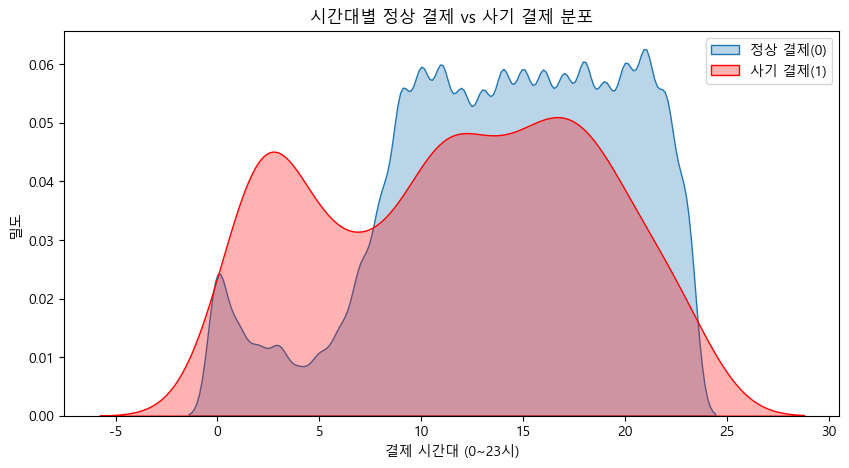

In [24]:

# 4. 해커들의 활동 시간대 시각화
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='정상 결제(0)', fill=True, alpha=0.3)
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='사기 결제(1)', fill=True, alpha=0.3, color='red')
plt.title('시간대별 정상 결제 vs 사기 결제 분포')
plt.xlabel('결제 시간대 (0~23시)')
plt.ylabel('밀도')
plt.legend()
plt.show()

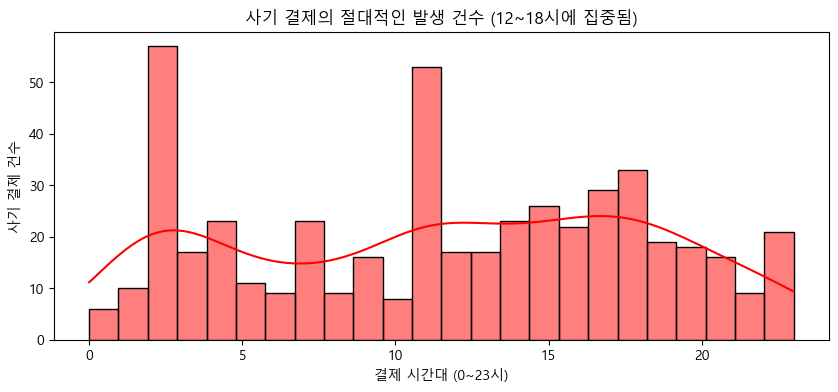

In [25]:
# 1. 절대량(Volume) 시각화: 수강생들을 속이는(?) 그래프
# "여러분, 사기 결제가 언제 가장 많이 일어났는지 붉은색 그래프로 그려봅시다."
plt.figure(figsize=(10, 4))
sns.histplot(data=df[df['Class'] == 1], x='Hour', bins=24, color='red', kde=True)
plt.title('사기 결제의 절대적인 발생 건수 (12~18시에 집중됨)')
plt.xlabel('결제 시간대 (0~23시)')
plt.ylabel('사기 결제 건수')
plt.show()

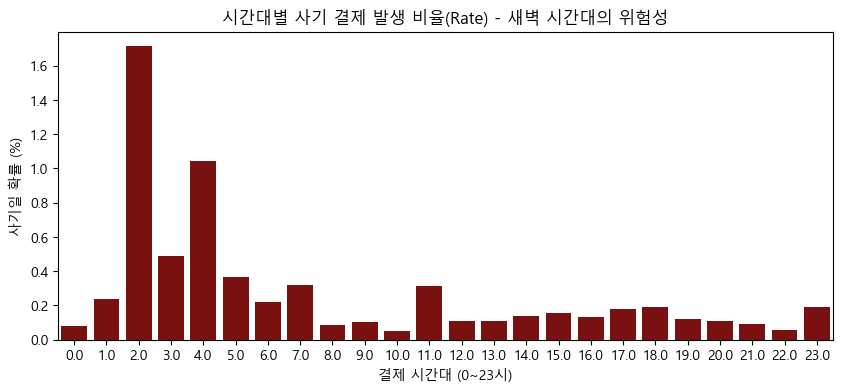

In [26]:
# 2. 비율(Rate) 시각화: 데이터 이면의 진실
# "시간대별 전체 결제 건수 대비 사기 결제 건수의 '비율'을 다시 계산해 봅시다."
# groupby를 이용해 각 시간대별 Class(0과 1)의 평균을 구하면 그게 곧 사기 비율이 됩니다.
fraud_rate = df.groupby('Hour')['Class'].mean() * 100

plt.figure(figsize=(10, 4))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values, color='darkred')
plt.title('시간대별 사기 결제 발생 비율(Rate) - 새벽 시간대의 위험성')
plt.ylabel('사기일 확률 (%)')
plt.xlabel('결제 시간대 (0~23시)')
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 준비 (시간과 금액은 스케일링 적용)
X = df.drop(['Class', 'Time'], axis=1) # 정답(Class)과 원본 Time 제거
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# 2. 학습/테스트 데이터 분리 (불균형 유지를 위해 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"학습용 데이터: 정상 {sum(y_train==0)}건, 사기 {sum(y_train==1)}건")

# 3. 모델 A: 일반 AI (가중치 없음)
model_default = LogisticRegression(max_iter=1000)
model_default.fit(X_train, y_train)
pred_default = model_default.predict(X_test)

# 4. 모델 B: 깐깐한 AI (사기꾼 놓치면 페널티 부여)
# 핵심 코드: class_weight='balanced'
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)
pred_balanced = model_balanced.predict(X_test)

# SMOTE를 활용한 인공지능형 데이터 증강 (Oversampling)
from imblearn.over_sampling import SMOTE

# 1. SMOTE 적용 전 데이터 개수 확인
print("[SMOTE 적용 전 학습 데이터 비율]")
print(f"정상 거래(0): {sum(y_train==0)}건")
print(f"사기 거래(1): {sum(y_train==1)}건")
print("-" * 40)

# 2. SMOTE 알고리즘 적용
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. SMOTE 적용 후 데이터 개수 확인
print("[SMOTE 적용 후 학습 데이터 비율]")
print(f"정상 거래(0): {sum(y_train_smote==0)}건")
print(f"사기 거래(1): {sum(y_train_smote==1)}건")
print("-" * 40)

# 4. 증강된 데이터로 3번째 AI(SMOTE 모델) 학습
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)
pred_smote = model_smote.predict(X_test)

# 5. 최종 3대 AI 모델 성적표 비교 (정확도 vs 재현율)
print("\n[최종: 3대 AI 모델 성적표 비교]")
print(f"1. 일반 AI   -> 정확도: {accuracy_score(y_test, pred_default)*100:.2f}% | 재현율: {recall_score(y_test, pred_default)*100:.2f}%")
print(f"2. 페널티 AI -> 정확도: {accuracy_score(y_test, pred_balanced)*100:.2f}% | 재현율: {recall_score(y_test, pred_balanced)*100:.2f}%")
print(f"3. SMOTE AI  -> 정확도: {accuracy_score(y_test, pred_smote)*100:.2f}% | 재현율: {recall_score(y_test, pred_smote)*100:.2f}%")


학습용 데이터: 정상 227451건, 사기 394건
[SMOTE 적용 전 학습 데이터 비율]
정상 거래(0): 227451건
사기 거래(1): 394건
----------------------------------------
[SMOTE 적용 후 학습 데이터 비율]
정상 거래(0): 227451건
사기 거래(1): 227451건
----------------------------------------

[최종: 3대 AI 모델 성적표 비교]
1. 일반 AI   -> 정확도: 99.92% | 재현율: 65.31%
2. 페널티 AI -> 정확도: 97.35% | 재현율: 90.82%
3. SMOTE AI  -> 정확도: 97.25% | 재현율: 90.82%


c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_waterfall.py:638: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\ekfla\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


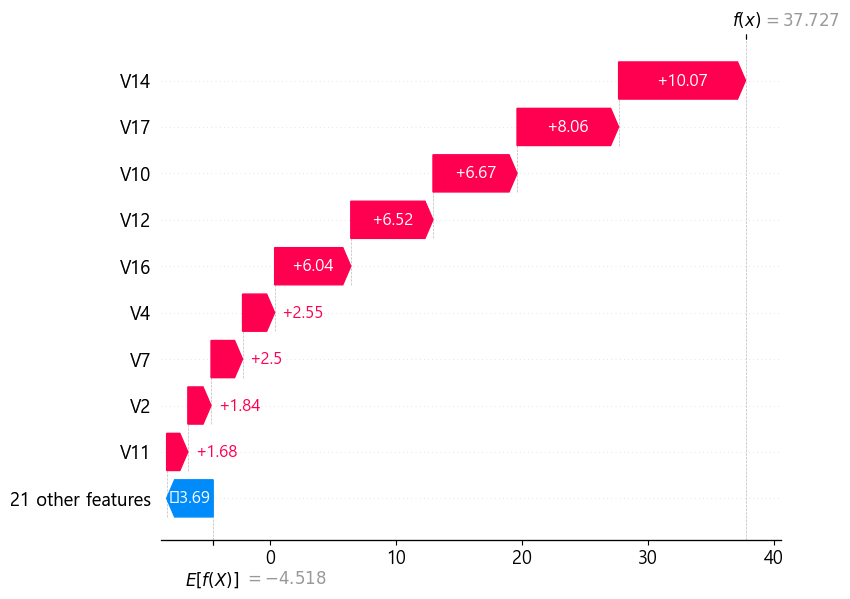

In [28]:
# (미리 pip install shap 실행 안내 필요)
import shap

# Colab에서 자바스크립트 시각화 허용
shap.initjs()

# 1. SHAP 설명기(Explainer) 초기화 (빠른 연산을 위해 선형 모델용 LinearExplainer 사용)
explainer = shap.LinearExplainer(model_balanced, X_train)

# 2. 분석할 타겟: 테스트 데이터 중 '실제 사기(1)'였던 첫 번째 고객 데이터
fraud_target = X_test[y_test == 1].iloc[[0]]

# 3. SHAP Value 계산
shap_values = explainer.shap_values(fraud_target)

# 4. Waterfall Plot(폭포수 차트) 시각화
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[0], feature_names=X.columns)

In [29]:
# !pip install lime

LIME을 활용하여 특정 결제의 사기 판정 이유를 분석합니다...


c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


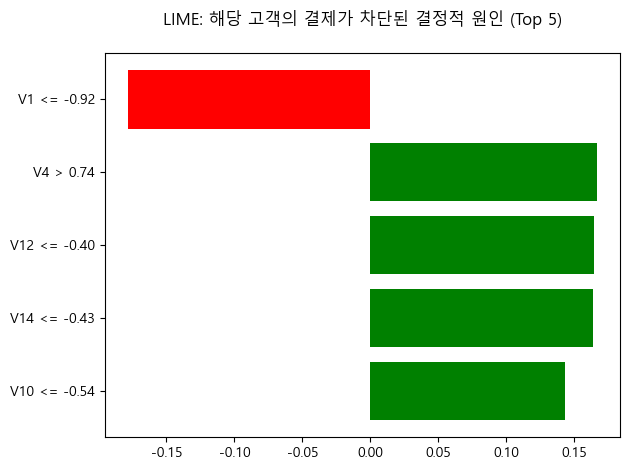

In [30]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

print("LIME을 활용하여 특정 결제의 사기 판정 이유를 분석합니다...")

# 1. LIME 설명기(Explainer) 초기화
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['정상 결제(0)', '사기 결제(1)'],
    mode='classification',
    random_state=42
)

# 2. 분석할 타겟 고객 선정 
target_data = X_test[y_test == 1].iloc[0]

# 3. LIME 설명 생성
# num_features=5 를 주어, 가장 강력한 영향을 미친 상위 5개 원인만 뽑아냅니다.
exp = explainer_lime.explain_instance(
    data_row=target_data.values,
    predict_fn=model_balanced.predict_proba,
    num_features=5 
)

# 4. 결과 시각화 
fig = exp.as_pyplot_figure()
plt.title("LIME: 해당 고객의 결제가 차단된 결정적 원인 (Top 5)", pad=20)
plt.tight_layout()
plt.show()


🌐 PDP 분석: AI는 '결제 시간대(Hour)'를 전반적으로 어떻게 평가하고 있을까?


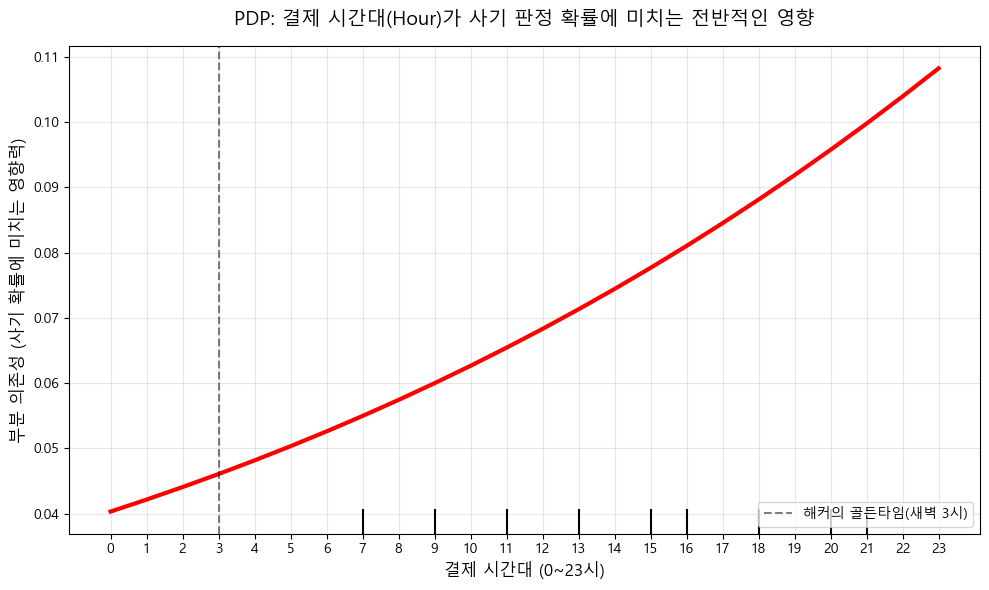

In [31]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 깨짐 방지 세팅 (상단에 이미 되어있다고 가정)

print("🌐 PDP 분석: AI는 '결제 시간대(Hour)'를 전반적으로 어떻게 평가하고 있을까?")

fig, ax = plt.subplots(figsize=(10, 6))

# 1. PDP 그래프 생성
# estimator: 학습이 완료된 모델 (여기서는 FDS의 model_balanced 사용)
# X: 기준이 될 데이터셋 (주로 학습 데이터 사용)
# features: 분석하고 싶은 컬럼명 리스트 (['Hour'] 또는 인덱스 번호)
# kind='average': 전체 평균적인 영향력(PDP)만 선으로 표시
pdp_display = PartialDependenceDisplay.from_estimator(
    estimator=model_balanced, 
    X=X_train, 
    features=['Hour'], 
    kind='average',
    ax=ax,
    line_kw={'color': 'red', 'linewidth': 3} # 그래프 선 스타일 지정
)

# 2. 그래프 시각화 디테일 설정
plt.title("PDP: 결제 시간대(Hour)가 사기 판정 확률에 미치는 전반적인 영향", fontsize=14, pad=15)
plt.xlabel("결제 시간대 (0~23시)", fontsize=12)
plt.ylabel("부분 의존성 (사기 확률에 미치는 영향력)", fontsize=12)

# 이론으로 배웠던 '해커의 골든타임'에 점선 추가
plt.axvline(x=3, color='black', linestyle='--', alpha=0.5, label='해커의 골든타임(새벽 3시)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

🚀 선형 모델의 한계를 극복하기 위해 랜덤포레스트로 AI를 교체합니다!


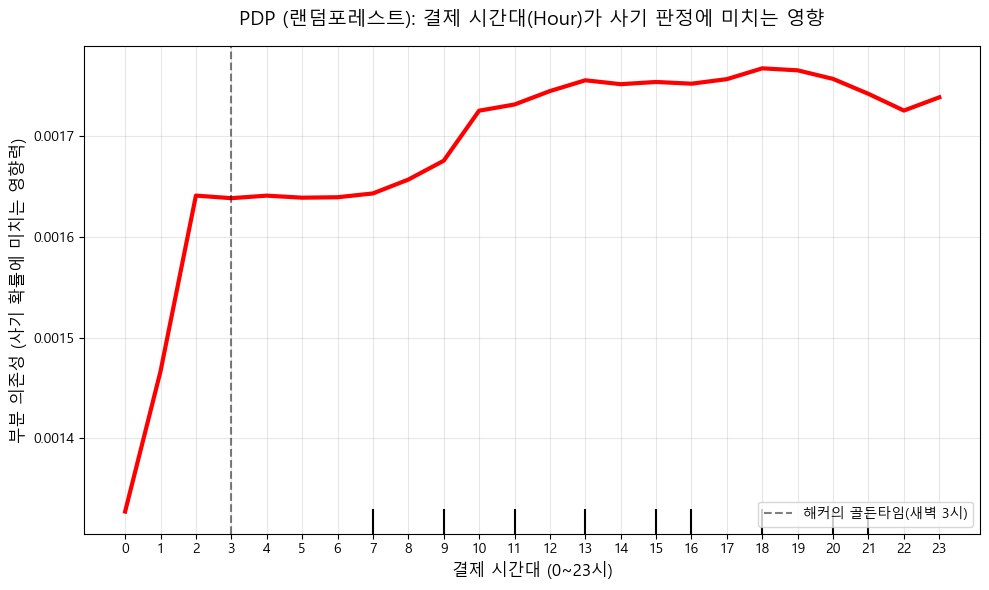

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

print("🚀 선형 모델의 한계를 극복하기 위해 랜덤포레스트로 AI를 교체합니다!")

# 1. 비선형 모델(Random Forest)로 FDS 모델 재학습
# (이전 실습의 X_train_smote, y_train_smote 데이터를 그대로 사용합니다)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced_subsample')
rf_model.fit(X_train, y_train)

# 2. PDP 그래프 생성 (이제 산봉우리가 나타납니다!)
fig, ax = plt.subplots(figsize=(10, 6))

pdp_display = PartialDependenceDisplay.from_estimator(
    estimator=rf_model, # 로지스틱 회귀 대신 랜덤포레스트 모델 투입
    X=X_train, 
    features=['Hour'], 
    kind='average',
    ax=ax,
    line_kw={'color': 'red', 'linewidth': 3}
)

plt.title("PDP (랜덤포레스트): 결제 시간대(Hour)가 사기 판정에 미치는 영향", fontsize=14, pad=15)
plt.xlabel("결제 시간대 (0~23시)", fontsize=12)
plt.ylabel("부분 의존성 (사기 확률에 미치는 영향력)", fontsize=12)

# 해커의 골든타임 표시
plt.axvline(x=3, color='black', linestyle='--', alpha=0.5, label='해커의 골든타임(새벽 3시)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()